# 🔵 Ejercicio 1: Predicción del Precio del Dólar

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import joblib

In [7]:
df = pd.read_csv("../data/dolar_data.csv")
df.head()

,Dia,Inflacion,Tasa_interes,Precio_Dolar
0,1,0.022484,5.463089,4024.833598
1,2,0.019309,5.954708,4000.546337
2,3,0.023238,4.300716,3979.622045
3,4,0.027615,5.281485,3940.361345
4,5,0.018829,4.674679,4016.930225


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Dia           500 non-null    int64  
 1   Inflacion     500 non-null    float64
 2   Tasa_interes  500 non-null    float64
 3   Precio_Dolar  500 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 15.8 KB


,Dia,Inflacion,Tasa_interes,Precio_Dolar
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,0.020034,5.015913,5211.771934
std,144.481833,0.004906,0.488999,723.895212
min,1.000000,0.003794,3.651557,3940.361345
25%,125.750000,0.016498,4.702354,4604.884954
50%,250.500000,0.020064,5.014266,5218.791143
75%,375.250000,0.023184,5.325621,5825.235279
max,500.000000,0.039264,6.316191,6553.598583


In [10]:
corr = df.corr(numeric_only=True)
corr

,Dia,Inflacion,Tasa_interes,Precio_Dolar
Dia,1.000000,0.021805,0.076006,0.997579
Inflacion,0.021805,1.000000,-0.075671,0.019595
Tasa_interes,0.076006,-0.075671,1.000000,0.074299
Precio_Dolar,0.997579,0.019595,0.074299,1.000000


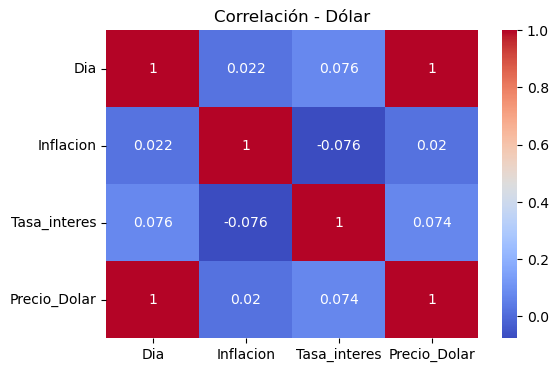

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación - Dólar")
plt.show()

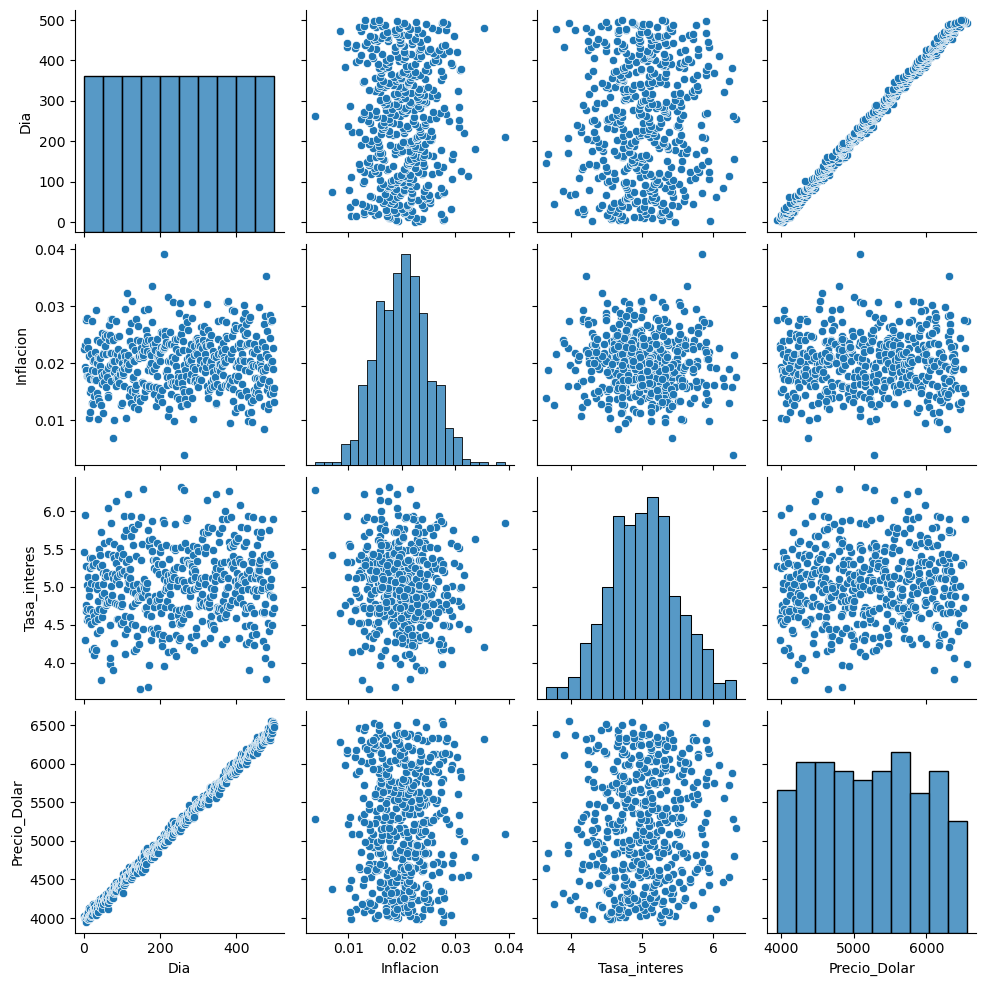

In [12]:
sns.pairplot(df)
plt.show()

In [14]:
X = df[["Dia", "Inflacion", "Tasa_interes"]]
y = df["Precio_Dolar"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 2376.97087657247
RMSE: 48.75418829775007
R2: 0.9963128117569109


In [18]:
import pandas as pd

coef = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": model.coef_
}).sort_values(by="Coeficiente", key=abs, ascending=False)

coef, model.intercept_

(       Variable  Coeficiente
 1     Inflacion  -870.731708
 0           Dia     4.984339
 2  Tasa_interes    -1.377431,
 np.float64(3985.783290894244))

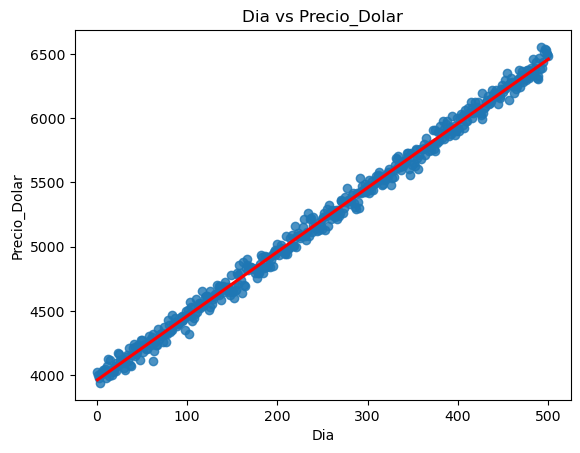

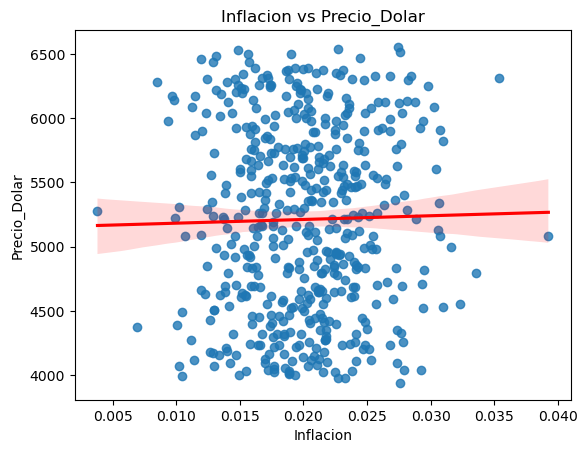

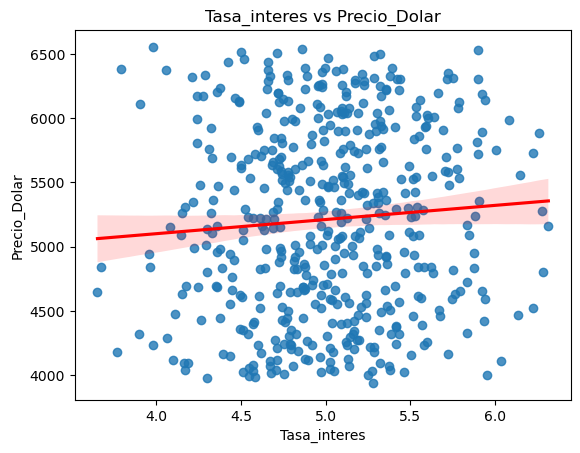

In [19]:
for col in X.columns:
    sns.regplot(x=df[col], y=df["Precio_Dolar"], line_kws={"color":"red"})
    plt.title(f"{col} vs Precio_Dolar")
    plt.show()

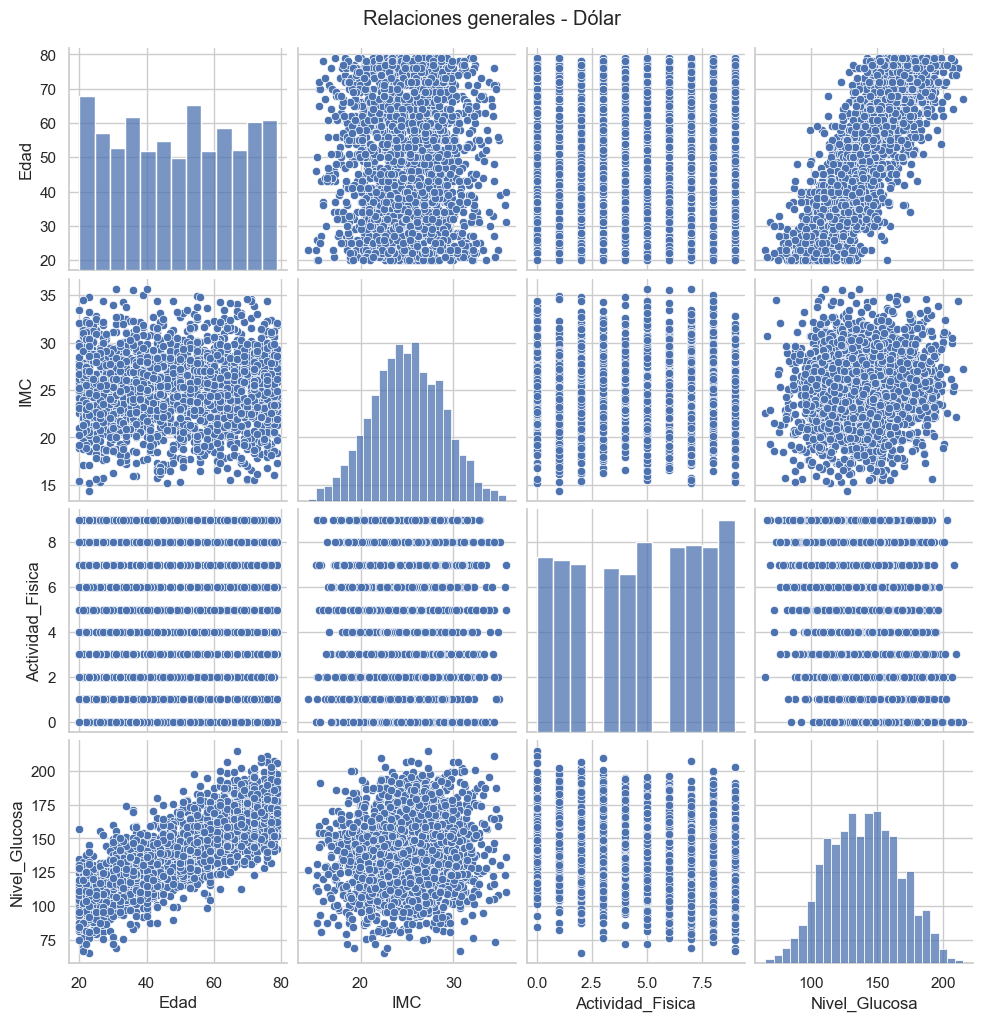

In [97]:
sns.pairplot(df)
plt.suptitle("Relaciones generales - Dólar", y=1.02)
plt.show()

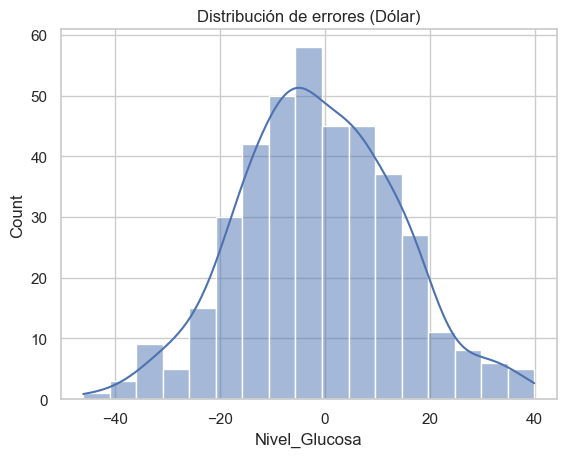

In [100]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Distribución de errores (Dólar)")
plt.show()

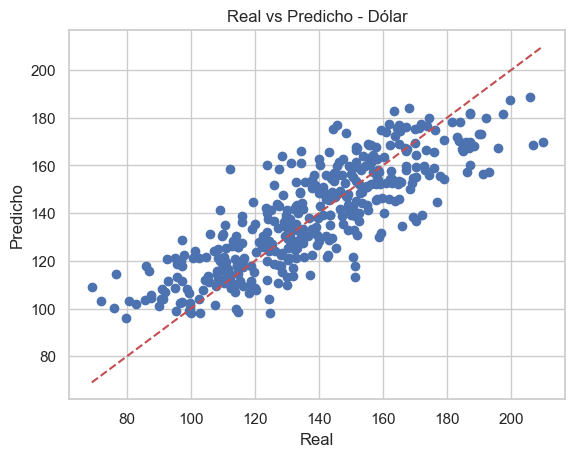

In [101]:
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho - Dólar")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [21]:
import joblib
joblib.dump(model, "../models/modelo_dolar.pkl")

['../models/modelo_dolar.pkl']

# 🔵 Ejercicio 2: Predicción del Nivel de Glucosa

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

import joblib

sns.set(style="whitegrid")

In [76]:
df = pd.read_csv("../data/glucosa_data.csv")
df.head()

,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
0,42,13.466414,1,141.840332
1,67,23.455602,1,171.937432
2,71,25.765184,8,155.504232
3,48,24.079550,2,115.865231
4,35,24.426649,7,115.698730


In [79]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Edad              2000 non-null   int64  
 1   IMC               2000 non-null   float64
 2   Actividad_Fisica  2000 non-null   int64  
 3   Nivel_Glucosa     2000 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 62.6 KB


,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,49.157000,24.963329,4.664500,139.630129
std,17.544494,3.983588,2.912247,27.342945
min,20.000000,10.586717,0.000000,43.415924
25%,34.000000,22.344522,2.000000,119.067583
50%,50.000000,25.028701,5.000000,139.967314
75%,64.000000,27.751081,7.000000,159.208487
max,79.000000,39.430227,9.000000,227.560693


In [80]:
df = df.dropna()

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))).any(axis=1)]
df.shape

(1981, 4)

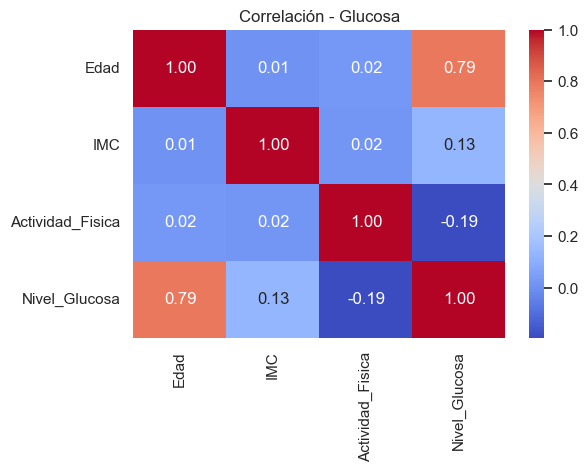

In [81]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación - Glucosa")
plt.show()

In [69]:
X = df[["Edad", "IMC", "Actividad_Fisica"]]
y = df["Nivel_Glucosa"]

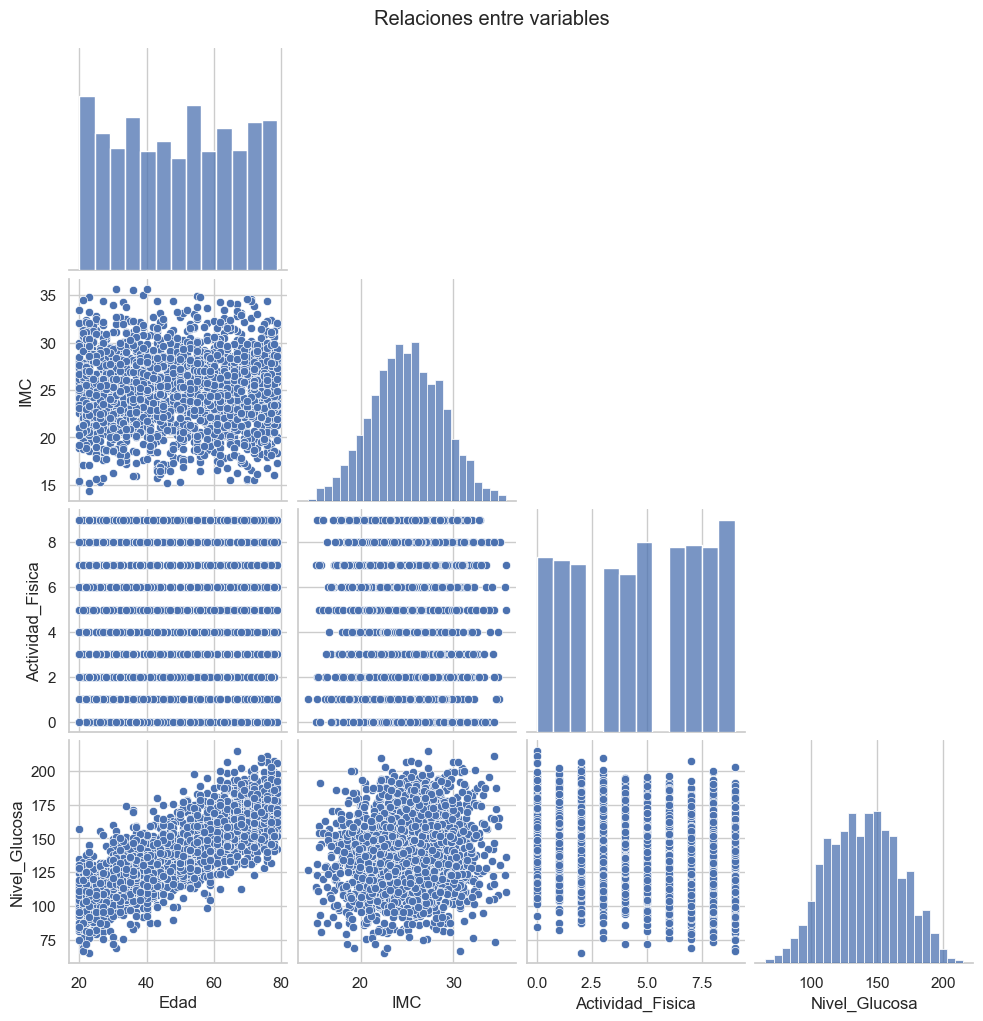

In [82]:
sns.pairplot(df, corner=True)
plt.suptitle("Relaciones entre variables", y=1.02)
plt.show()

In [83]:
X = df[["Edad", "IMC", "Actividad_Fisica"]]
y = df["Nivel_Glucosa"]

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [85]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [86]:
y_pred_lr = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("REGRESIÓN LINEAL")
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

REGRESIÓN LINEAL
MSE: 223.90432680758124
RMSE: 14.963432988708883
R2: 0.694751119580852


In [87]:
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": model_lr.coef_
}).sort_values(by="Coeficiente", key=abs, ascending=False)

coef_df

,Variable,Coeficiente
2,Actividad_Fisica,-2.009684
0,Edad,1.225616
1,IMC,0.913509


In [88]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge", Ridge(alpha=1.0))
])

pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


In [89]:
y_pred_poly = pipe.predict(X_test)

mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("POLINÓMICO + RIDGE")
print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("R2:", r2_poly)

POLINÓMICO + RIDGE
MSE: 225.9511798741325
RMSE: 15.031672557441254
R2: 0.6919606437742625


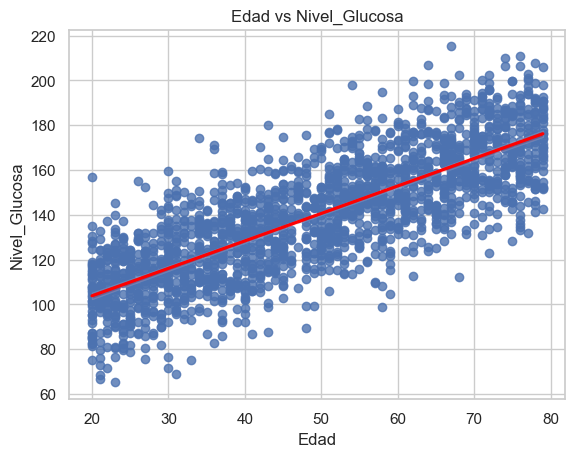

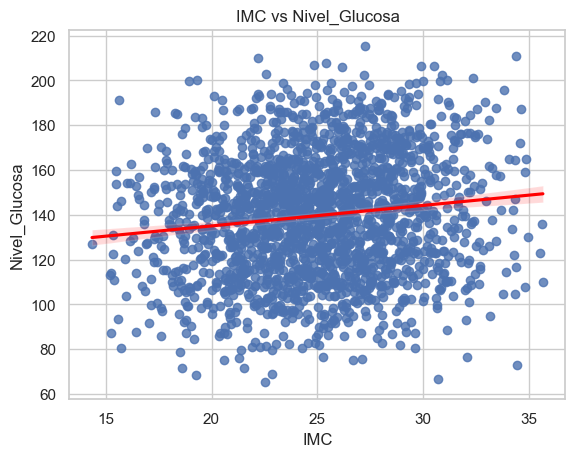

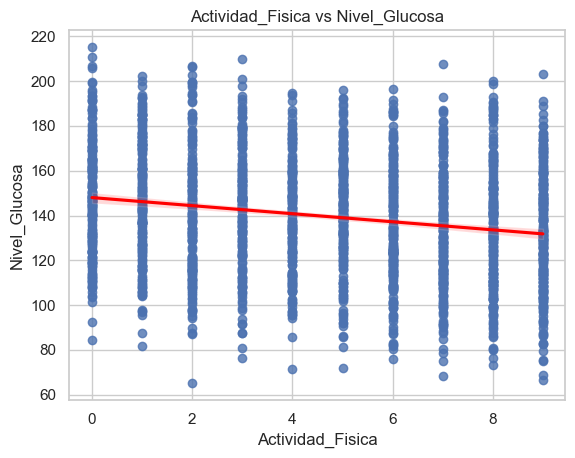

In [93]:
for col in X.columns:
    plt.figure()
    sns.regplot(x=df[col], y=y, line_kws={"color": "red"})
    plt.title(f"{col} vs Nivel_Glucosa")
    plt.xlabel(col)
    plt.ylabel("Nivel_Glucosa")
    plt.show()

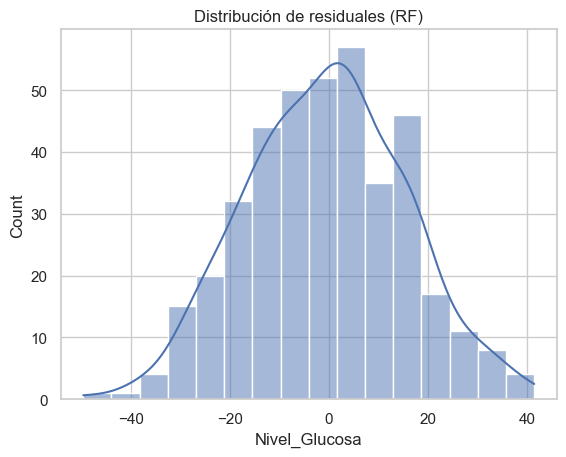

In [94]:
residuals = y_test - y_pred_rf

sns.histplot(residuals, kde=True)
plt.title("Distribución de residuales (RF)")
plt.show()

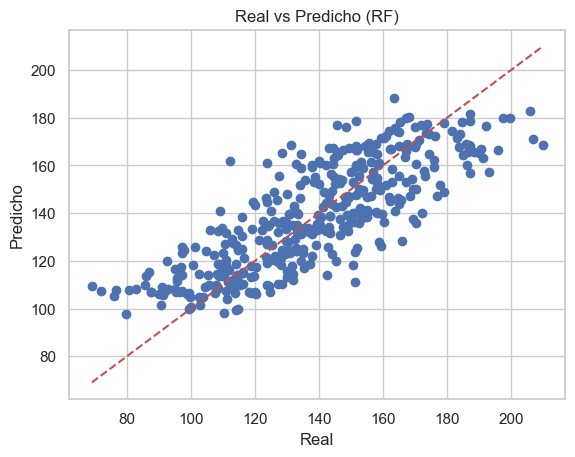

In [95]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho (RF)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [96]:
# Elige el mejor por R2 en test (normalmente RF o Polinómico)
best_model = model_rf if r2_rf >= max(r2_lr, r2_poly) else pipe
joblib.dump(best_model, "../models/modelo_glucosa.pkl")

['../models/modelo_glucosa.pkl']

# 🟣 Ejercicio 3: Predicción del Consumo de Energía

In [33]:
df = pd.read_csv("../data/energia_data.csv")
df.head()

,Temperatura,Hora,Dia_Semana,Consumo_Energia
0,28.891805,1,1,401.990602
1,22.244071,2,2,334.846911
2,20.909006,3,3,326.926080
3,24.983128,4,4,383.016951
4,24.149077,5,5,388.748151


In [34]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperatura      10000 non-null  float64
 1   Hora             10000 non-null  int64  
 2   Dia_Semana       10000 non-null  int64  
 3   Consumo_Energia  10000 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 312.6 KB


,Temperatura,Hora,Dia_Semana,Consumo_Energia
count,10000.000000,10000.000000,10000.00000,10000.000000
mean,24.924793,12.493600,3.99940,400.043522
std,5.004022,6.921297,2.00005,63.825152
min,5.387999,1.000000,1.00000,185.196384
25%,21.578541,6.000000,2.00000,356.735276
50%,24.900520,12.000000,4.00000,399.270398
75%,28.310962,18.000000,6.00000,443.134098
max,44.631189,24.000000,7.00000,631.093191


In [35]:
df = df.dropna()

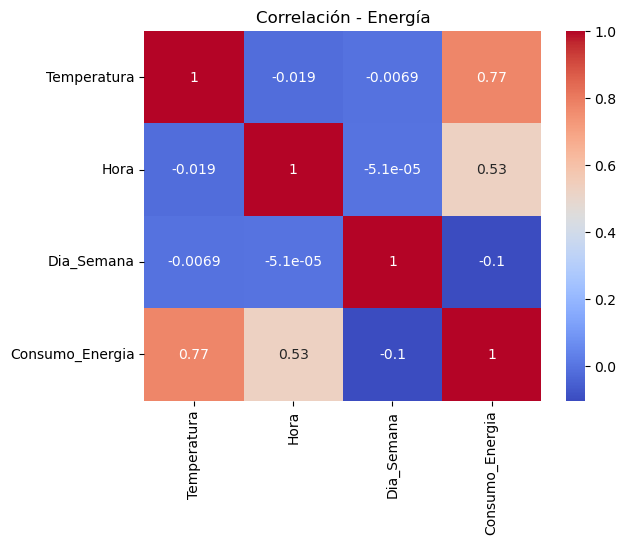

In [36]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlación - Energía")
plt.show()

In [37]:
X = df[["Temperatura", "Hora", "Dia_Semana"]]
y = df["Consumo_Energia"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 20.400521491192862
R2: 0.899896878715178


In [39]:
coef = pd.DataFrame(model.coef_, X.columns, columns=["Coeficiente"])
coef

,Coeficiente
Temperatura,9.956855
Hora,5.004773
Dia_Semana,-3.082766


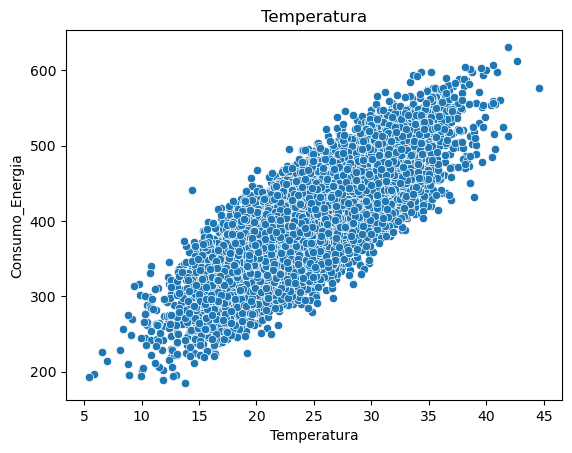

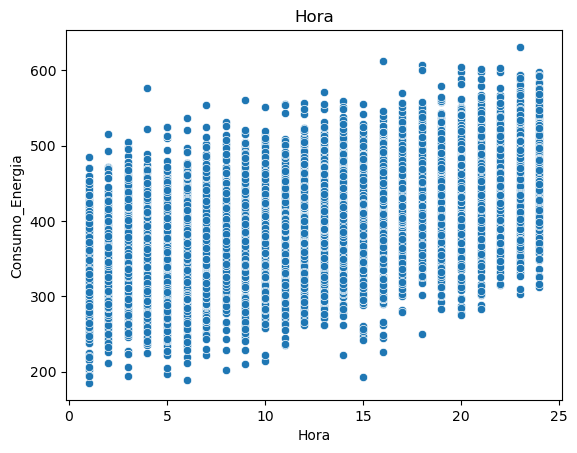

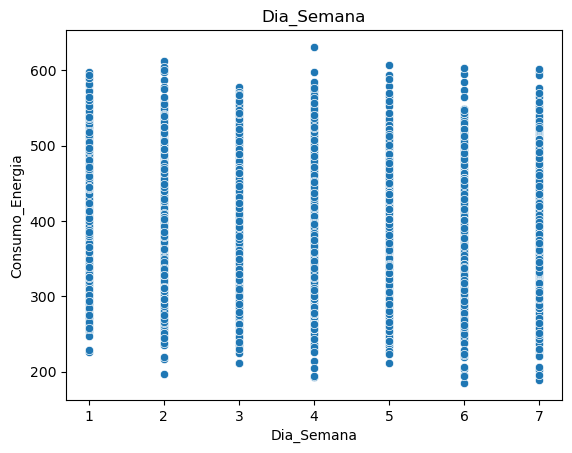

In [40]:
for col in X.columns:
    sns.scatterplot(x=df[col], y=y)
    plt.title(col)
    plt.show()

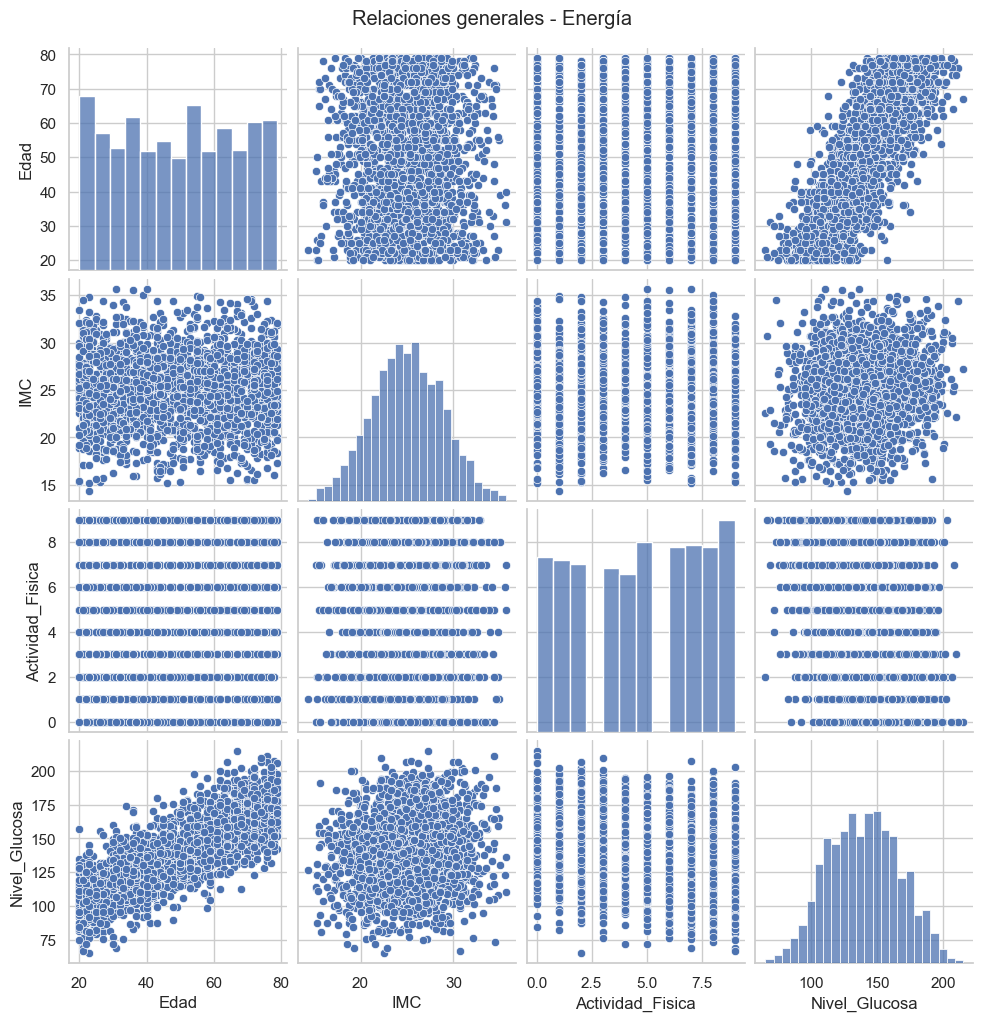

In [102]:
sns.pairplot(df)
plt.suptitle("Relaciones generales - Energía", y=1.02)
plt.show()

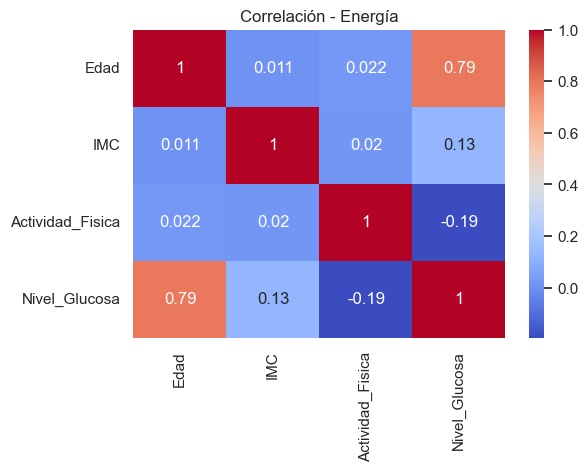

In [104]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlación - Energía")
plt.show()

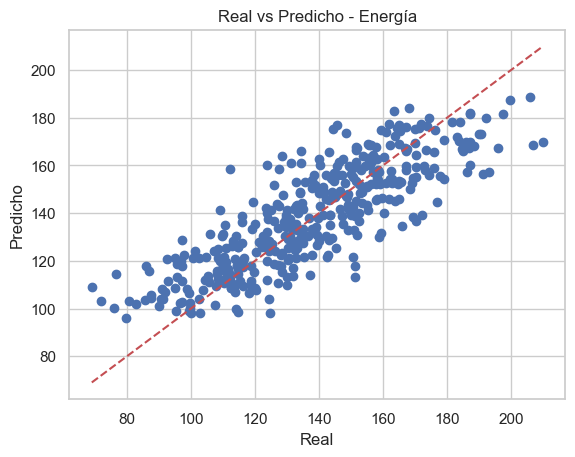

In [105]:
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho - Energía")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

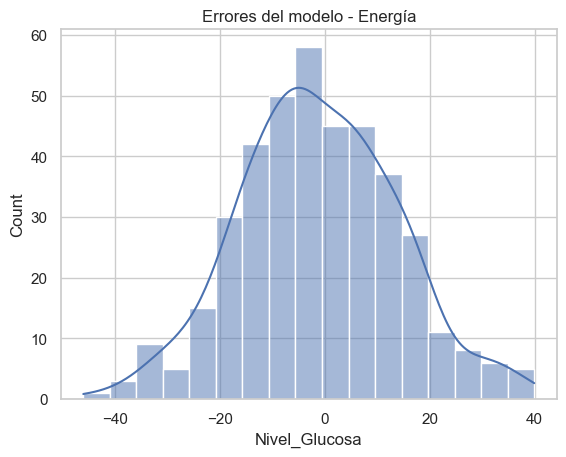

In [106]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Errores del modelo - Energía")
plt.show()

In [41]:
joblib.dump(model, "../models/modelo_energia.pkl")

['../models/modelo_energia.pkl']